# Training Loop Example

In this notebook, we implement a training loop for a basic transformer model in pyTorch on the tiny shakespeare data set, as a hommage to nanoGPT from Andrej Karpathy's brilliant [Neural Networks: Zero to Hero](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ) series.

## Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from matplotlib.pylab import plt

In [2]:
from adam import Adam

In [3]:
file_path = "../data/input.txt"

with open(file_path, "r") as f:
    dataset = list(f.read())

## Dataset Preparation

In [4]:
chars = sorted(set(dataset))
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {ctoi[c]:c for c in ctoi.keys()}

In [5]:
encode = lambda s: [ctoi[c] for c in s]
decode = lambda s: "".join([itoc[i] for i in s])

In [6]:
data = encode(dataset)
data_tensor = torch.tensor(data, dtype=torch.long)
data_size = data_tensor.size(dim=0)

In [7]:
split = round(data_size*0.9)
data_train = data_tensor[:split]
data_val = data_tensor[split:]

In [8]:
len_train = data_train.size(dim=0)
len_val = data_val.size(dim=0)

In [9]:
print(f"length of training set: {len_train}")
print(f"length of validation set: {len_val}")

length of training set: 1003855
length of validation set: 111539


In [10]:
batch_size = 64

In [11]:
def get_batch(data: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    batch_indizes = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in batch_indizes])
    y = torch.stack([data[i+1:i+block_size+1] for i in batch_indizes])
    return x, y

## Model Initialization

In [12]:
class Model(nn.Module):

    def __init__(self, block_size: int, vocab_size: int, d_model: int, nhead: int, num_layers: int):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, d_model)

        self.positional_embedding = nn.Embedding(block_size, d_model)
        self.register_buffer("causal_mask", torch.triu(torch.ones(block_size, block_size), diagonal=1).bool())

        self.encoding_layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(self.encoding_layer, num_layers, enable_nested_tensor=False)

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, inputs: torch.Tensor):
        T = inputs.size(0) if inputs.dim() == 1 else inputs.size(1)

        embeddings = self.token_embedding(inputs)
        pos = torch.arange(T, device=inputs.device)
        pos_embeddings = self.positional_embedding(pos)
        embeddings += pos_embeddings

        mask = self.causal_mask[:T, :T]
        transformer_outputs = self.transformer(embeddings, mask)
        logits = self.lm_head(transformer_outputs)
        return logits

In [13]:
block_size = 128
vocab_size = len(chars)
d_model = 128
nhead = 4
num_layers = 4

## Training Loop (our Adam)

### Initialization and Setup

In [14]:
model = Model(block_size, vocab_size, d_model, nhead, num_layers)
model.train()

Model(
  (token_embedding): Embedding(65, 128)
  (positional_embedding): Embedding(128, 128)
  (encoding_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_feature

In [15]:
params = model.parameters()
optim = Adam(params, lr=0.001)

In [16]:
losses = []

In [ ]:
num_iters = 10000

### Actual training loop

In [21]:
for _ in tqdm(range(num_iters)):
    sequence_idx = np.random.randint(0, len_train - block_size - 1)
    x, y = get_batch(data_train)
    
    logits = model(x)
    B, T, C = logits.shape
    logits = logits.view(B*T, C)
    targets = y.view(B*T)
    loss = F.cross_entropy(logits, targets)

    losses.append(loss.item())

    optim.zero_grad()
    loss.backward()
    optim.step()

100%|██████████| 1000/1000 [08:27<00:00,  1.97it/s]


Text(0, 0.5, 'Loss')

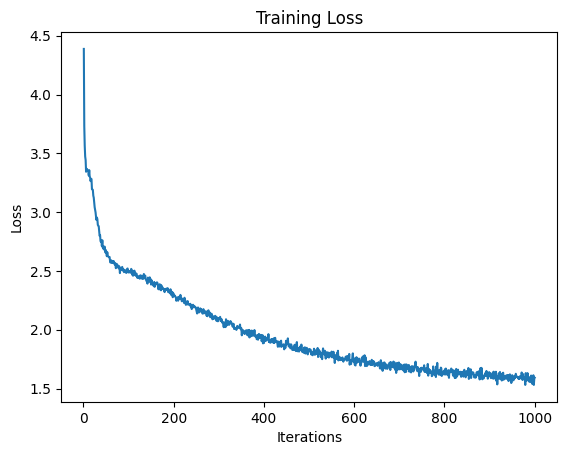

In [22]:
plt.plot(range(1,num_iters + 1), losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

### Validation

In [ ]:
model.eval()

val_losses = []

eval_iters = 500

with torch.no_grad():
    for _ in tqdm(range(eval_iters)):
        sequence_idx = np.random.randint(0, len_val - block_size - 1)
        x, y = get_batch(data_val)
        
        logits = model(x)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = y.view(B*T)
        loss = F.cross_entropy(logits, targets)

        val_losses.append(loss.item())

model.train()

val_loss = np.average(val_losses)
print(f"average validation loss with {eval_iters} iterations: {val_loss}")

100%|██████████| 200/200 [00:16<00:00, 11.87it/s]

average validation loss with 200 iterations: 1.671622166633606


## Sampling

In [ ]:
text_len = 2000

text = torch.tensor(encode("To be or not to be"), dtype=torch.long)

for _ in tqdm(range(text_len)):
    context = text[-block_size:]
    logits = model(context)
    next_logits = logits[-1]
    probs = F.softmax(next_logits)
    idx = torch.multinomial(probs, num_samples=1)
    text = torch.cat([text, idx])

text = decode(text.tolist())
print(text)

  0%|          | 0/400 [00:00<?, ?it/s]/var/folders/xk/wh_dv4fd785263srbm07380m0000gn/T/ipykernel_37824/395469023.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(next_logits)
100%|██████████| 400/400 [00:02<00:00, 171.73it/s]

To be or not to be me, said
That's given an Appranticous:
A this setfull nobe and gentlen, thoughts, dest
by virty beins at and tearous, coundstill, and lubbelse.

WARBCIO:
Ay, and thy granneraling king for Lal!

AUTOLY't, weak to Rick, attering; but yourself
Marcious thou be her my hatests, Supers for a cout spokes!
Foed no, for heard, dhall we she joinus, othir,
Should wounds ounder in feseshns thise his?

ROMENE


## Training Loop (torch.optim.Adam)

### Initialization and Setup

In [27]:
model2 = Model(block_size, vocab_size, d_model, nhead, num_layers)
model2.train()

Model(
  (token_embedding): Embedding(65, 128)
  (positional_embedding): Embedding(128, 128)
  (encoding_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_feature

In [28]:
params = model2.parameters()
optim2 = torch.optim.Adam(params, lr=0.001)

In [29]:
losses = []

In [ ]:
num_iters = 10000

### Actual training loop

In [31]:
for _ in tqdm(range(num_iters)):
    sequence_idx = np.random.randint(0, len_train - block_size - 1)
    x, y = get_batch(data_train)
    
    logits = model2(x)
    B, T, C = logits.shape
    logits = logits.view(B*T, C)
    targets = y.view(B*T)
    loss = F.cross_entropy(logits, targets)

    losses.append(loss.item())

    optim2.zero_grad()
    loss.backward()
    optim2.step()

100%|██████████| 1000/1000 [08:22<00:00,  1.99it/s]


Text(0, 0.5, 'Loss')

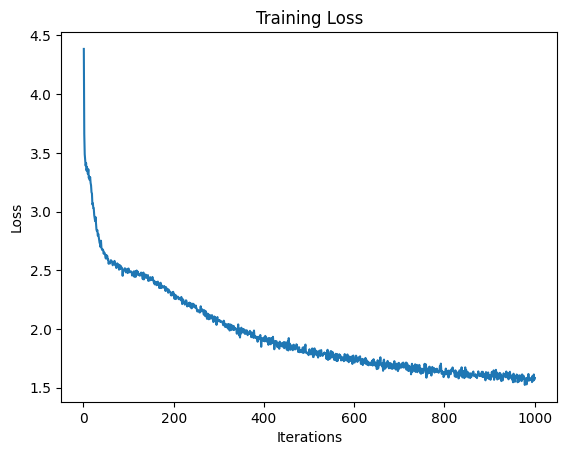

In [32]:
plt.plot(range(1,num_iters + 1), losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

### Validation

In [33]:
model2.eval()

val_losses = []

eval_iters = 500

with torch.no_grad():
    for _ in tqdm(range(eval_iters)):
        sequence_idx = np.random.randint(0, len_val - block_size - 1)
        x, y = get_batch(data_val)
        
        logits = model2(x)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = y.view(B*T)
        loss = F.cross_entropy(logits, targets)

        val_losses.append(loss.item())

model2.train()

val_loss = np.average(val_losses)
print(f"average validation loss with {eval_iters} iterations: {val_loss}")

100%|██████████| 500/500 [00:41<00:00, 12.00it/s]

average validation loss with 500 iterations: 1.6572087457180023


## Sampling

In [ ]:
text_len = 2000

text2 = torch.tensor(encode("To be or not to be"), dtype=torch.long)

for _ in tqdm(range(text_len)):
    context = text2[-block_size:]
    logits = model(context)
    next_logits = logits[-1]
    probs = F.softmax(next_logits)
    idx = torch.multinomial(probs, num_samples=1)
    text2 = torch.cat([text2, idx])

text2 = decode(text2.tolist())
print(text2)

  0%|          | 0/400 [00:00<?, ?it/s]/var/folders/xk/wh_dv4fd785263srbm07380m0000gn/T/ipykernel_37824/3887920126.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(next_logits)
100%|██████████| 400/400 [00:02<00:00, 169.85it/s]

To be or not to be child oxford's romper he is,
And for he Riscome to your were kinds.
Tablet let him life is frier dom wails means
In this the lictaude. ay, our heavestery
I this fiar, fesind
With spoar Cabole!
Gecing Musiciasure, good k,'s e'leggace.

Gentleman:
Let he decksee, all-well thanks inle thee profes and till.

Gentleman:
Sirrahh'd didst is some.-Bam druns, but theresenge in oldelous the Date,
The purce
